In [1]:
import os
import sys
from os.path import join, expanduser

# --- Try the preferred import path ---
try:
    import find_jcmwave as jcmwave
    USING_FIND_JCMWAVE = True

except ImportError:
    USING_FIND_JCMWAVE = False

    # --- Fallback: manually append JCMsuite Python path ---
    home = expanduser('~')
    jcm_root = join(home, 'JCMwave/JCMsuite_6_4_8/ThirdPartySupport/Python')
    sys.path.append(jcm_root)

    try:
        import jcmwave
    except ImportError as e:
        raise ImportError(
            "Could not import jcmwave. Tried find_jcmwave and manual path.\n"
            f"Checked fallback path: {jcm_root}"
        ) from e

# Optional: print which path was used
if USING_FIND_JCMWAVE:
    print("Imported jcmwave via find_jcmwave")
else:
    print(f"Imported jcmwave via manual path: {jcm_root}")

Imported jcmwave via find_jcmwave


In [2]:
import sys
import numpy as np
import scipy.interpolate as si
import os
import scipy.optimize
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join, expanduser

#import find_jcmwave as jcmwave

import JCM_models.xray_compounds as xc
import JCM_models.jcm_plotting_utils as JCMgrid
from JCM_models import Shape, ShapeGenerator, Source, Cartesian, PostProcess, SimulationResult,write_project_files, eVnm_converter, make_json_safe

import pint

unit = pint.UnitRegistry()

import pandas as pd

import matplotlib as mpl

mpl.rcParams["font.family"] = ["sans"]
mpl.rcParams["font.serif"] = ["DejaVu Sans"]
jcmwave.daemon.shutdown()

In [3]:
import helper as h

In [4]:
#Generates the project files for the JCMsuite simulation, adjust the name of the folder if necessary
write_project_files("JCMfolder_test")


project.jcmpt written to JCMfolder_test/project.jcmpt
sources.jcmt written to JCMfolder_test/sources.jcmt
layout.jcmt written to JCMfolder_test/layout.jcmt
materials.jcmt written to JCMfolder_test/materials.jcmt


In [5]:
#Set up the JCMsuite daemon for parallel computing, adjust the parameters if necessary, take number of CPU cores into account
jcmwave.daemon.shutdown()
jcmwave.daemon.add_workstation(
    Hostname="localhost",
    Multiplicity=3,
    NThreads=12,
)

[1565085482, 600614125, 1897268351]

## Load exp data

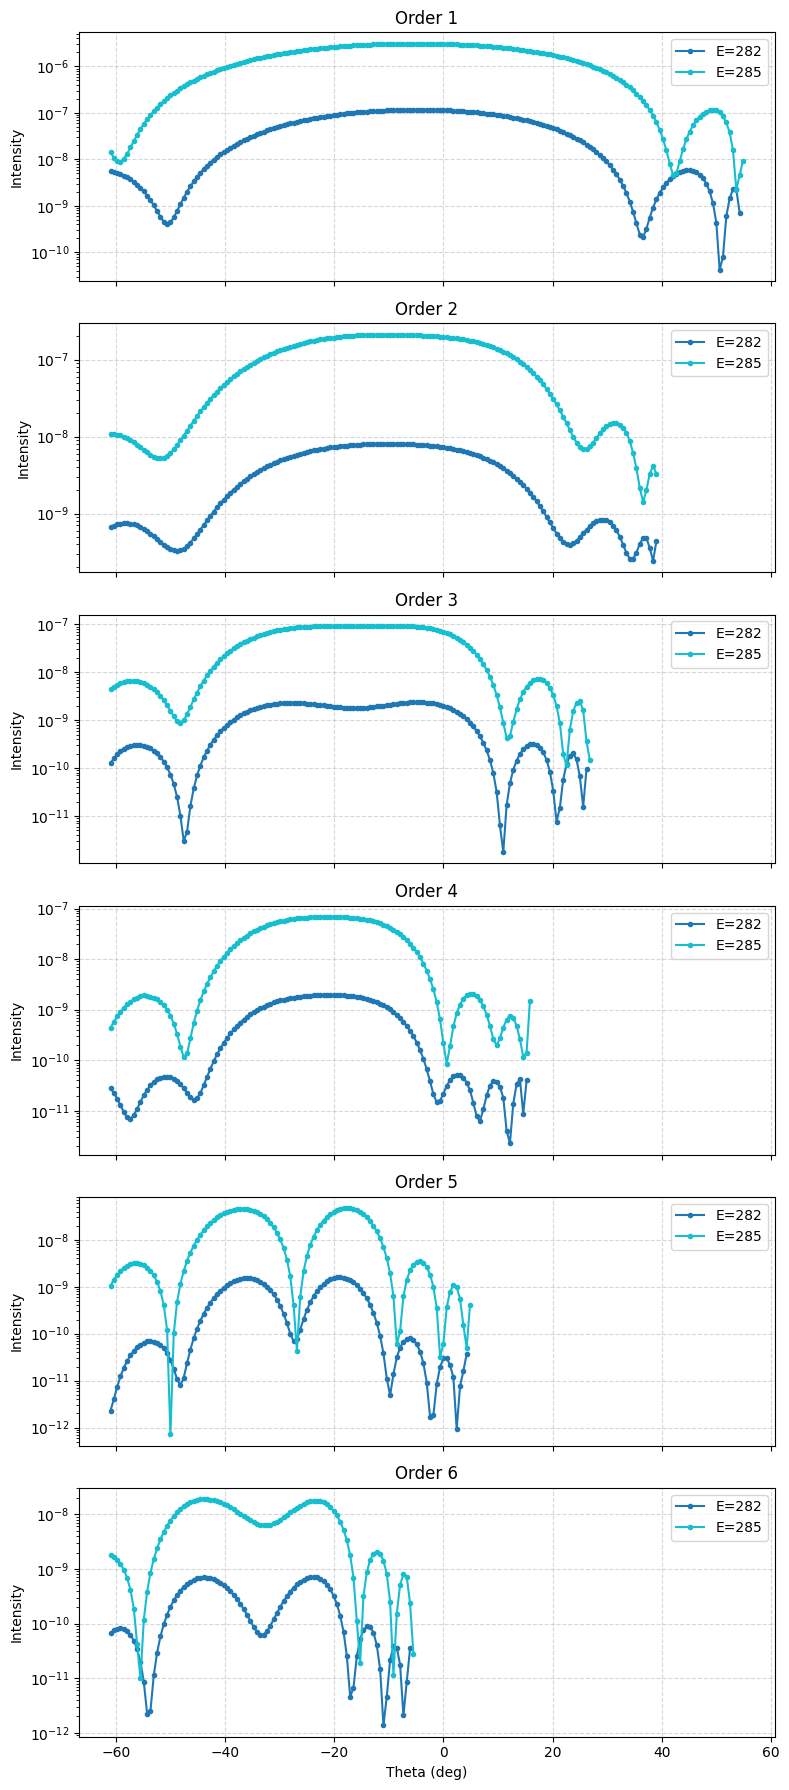

In [6]:
#Load exp data
exp_data = pd.read_csv("./test_data/forward_model_results_test.csv")
fig = h.plot_orders_multi(exp_data)

In [7]:
e_unique = exp_data["energy"].unique()
theta_unique = exp_data["theta"].unique()
nk_PMMA = np.array([0.99904226+0.00014477j, 0.99965732+0.00018251j])
nk_PS = np.array([0.99994264+6.00886481e-05j, 1.00502376+2.42369713e-03j])

## Test shape

In [8]:
#Test shape
slc = 0.7
top_offset = 2
bottom_offset = 2

keys = {'uol1': 1e-9,
        'fem_deg': 4,
        'pitch': 24,
        'width_1': 10,
        'width_2': 12,
        'width_3': 18,
        'width_4': 5,
        'height_1': 2,
        'height_2': 20,
        'height_3': 3,
        'height_bg': 20,
        }

pitch = keys['pitch']

width_1 = keys['width_1']
width_2 = keys['width_2']
width_3 = keys['width_3']
width_4 = keys['width_4']

height_1 = keys['height_1']
height_2 = keys['height_2']
height_3 = keys['height_3']

heights = [0,height_1, height_2, height_3]
widths = [width_1, width_2, width_3, width_4]

height_bg = keys['height_bg']

y = top_offset+bottom_offset+max(height_bg,sum(heights))

control_points = h.build_control_points(heights, widths)

computional_domain = ShapeGenerator('rectangle', {'height':y,'width':pitch},offset_y=-bottom_offset).flatten(centered=True)
bg = ShapeGenerator('rectangle', {'height':height_bg,'width':pitch}).flatten(centered=True)
#shape = ShapeGenerator('stack_trapezoids', {'height':heights,'width':widths}).flatten(centered=True)
shape = ShapeGenerator('bsplines', {'control_points':control_points}).flatten(centered=True)

shape = [
    Shape('ComputationalDomain',domain_id = 1,priority=-1,side_length_constraint=slc,points=computional_domain, nk = 1,boundary = ['TransparentBoundary','Periodic','TransparentBoundary','Periodic'] ),
    #Shape('shape',domain_id = 2,priority=2,side_length_constraint=slc,points=xy_list, nk = nk_PMMA ),
    Shape('shape',domain_id = 2,priority=2,side_length_constraint=slc,points=shape, nk = nk_PMMA ),
    Shape('shape_bg',domain_id = 3,priority=1,side_length_constraint=slc,points=bg, nk = nk_PS ),
]

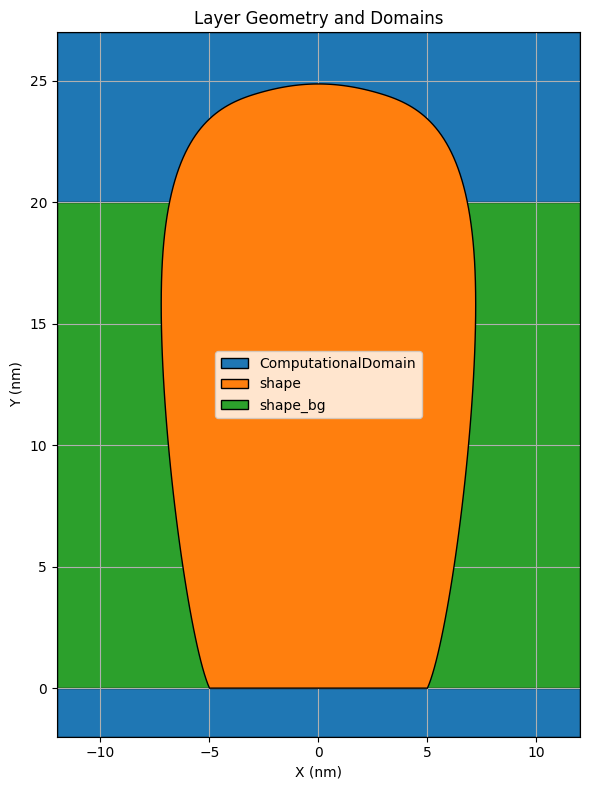

In [9]:
# Create a shared figure and axis
fig, ax = plt.subplots(figsize=(6, 8))

# Plot each shape
for s in shape:
    #s.plot(ax=ax)
    s.plot_colored_geometry(ax=ax)

# Final touches
ax.set_xlim(-pitch/2, pitch/2)
ax.set_ylim(-bottom_offset, y-bottom_offset)
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y (nm)")
ax.set_title("Layer Geometry and Domains")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Build objective

In [10]:
pp2 = PostProcess(
    mode="FourierTransform",
    field_bag_path="project_results/fieldbag.jcm",
    output_file_name="project_results/ft.jcm",
    normal_direction="Y",
    rotation = 'X:Z:-Y'
)
keys['postprocess']=[pp2]
slc = 0.7
top_offset = 2
bottom_offset = 2

def objective_JCMopt(return_scales=False,do_log=True, **kwargs):
    keys.update(kwargs)

    pitch = keys['pitch']

    width_1 = keys['width_1']
    width_2 = keys['width_2']
    width_3 = keys['width_3']
    width_4 = keys['width_4']

    height_1 = keys['height_1']
    height_2 = keys['height_2']
    height_3 = keys['height_3']

    heights = [0,height_1, height_2, height_3]
    widths = [width_1, width_2, width_3, width_4]

    height_bg = keys['height_bg']

    y = top_offset+bottom_offset+max(height_bg,sum(heights))

    control_points = h.build_control_points(heights, widths)

    computional_domain = ShapeGenerator('rectangle', {'height':y,'width':pitch},offset_y=-bottom_offset).flatten(centered=True)
    bg = ShapeGenerator('rectangle', {'height':height_bg,'width':pitch}).flatten(centered=True)
    shape = ShapeGenerator('bsplines', {'control_points':control_points}).flatten(centered=True)

    shape = [
        Shape('ComputationalDomain',domain_id = 1,priority=-1,side_length_constraint=slc,points=computional_domain, nk = 1,boundary = ['TransparentBoundary','Periodic','TransparentBoundary','Periodic'] ),
        Shape('shape',domain_id = 2,priority=2,side_length_constraint=slc,points=shape, nk = nk_PMMA ),
        Shape('shape_bg',domain_id = 3,priority=1,side_length_constraint=slc,points=bg, nk = nk_PS ),
    ]
    keys['shape']=shape 
    theta_calc = []
    E_calc = []
    job_ids = []
    
    for i,energy in enumerate(e_unique[:]):
        for theta in theta_unique[:]:
            keys['energy_index'] = 0
            s_eV = Source(energy,
                        polarization=[1, 0], 
                        angle_of_incidence=theta, 
                        phi=0, 
                        unit='eV',incidence='FromBelow')
            keys['source']=[s_eV]
            keys['energy_index'] = i  
            
            job_ids.append(jcmwave.solve('./JCMfolder_test/project.jcmpt',  keys=keys,temporary=True))
            theta_calc.append(theta)
            E_calc.append(energy)
        
    results, logs = jcmwave.daemon.wait(job_ids,verbose=False)
    all_dfs = []

    # Suppose you have a list of SimulationResult objects
    sim_results = SimulationResult.from_list(results)  

    for i, res in enumerate(sim_results):
        # Get DataFrame
        df = res.fourier[0].to_dataframe()

        # Add theta column from your external keys array
        df["theta"] = theta_calc[i]
        df["energy"] = E_calc[i]

        # Collect
        all_dfs.append(df)

    # Concatenate into one big DataFrame
    df_all = pd.concat(all_dfs, ignore_index=True)
    #return df_all

    merged_df = pd.merge(df_all, exp_data, left_on=['order', 'theta', 'energy'], right_on=['order', 'theta', 'energy'], how='inner')

    K = np.square(merged_df['Kx']*1e-9-merged_df['Kx_in']*1e-9) + np.square(merged_df['Kz']*1e-9-merged_df['Kz_in']*1e-9)+ np.square(merged_df['Ky']*1e-9-merged_df['Ky_in']*1e-9)
    merged_df['Intensity_calc_corrected_1'] = (
                merged_df["P_z"] *merged_df['cos_theta_out'] 
            )
    merged_df['Intensity_calc_rough'] = np.abs(np.exp(-K*np.square(keys['sigma']))*merged_df['Intensity_calc_corrected'])
    merged_df['Intensity_calc_rough_1'] = np.abs(np.exp(-K*np.square(keys['sigma']))*merged_df['Intensity_calc_corrected_1'])

    merged_df['intensity_norm'] = merged_df['intensity']/np.max(merged_df['intensity'])
    merged_df['Intensity_calc_rough_norm'] = merged_df['Intensity_calc_rough_1']/np.max(merged_df['Intensity_calc_rough_1'])

    calc = np.asarray(merged_df['Intensity_calc_rough_norm'])
    exp = np.asarray(merged_df['intensity_norm'])

    if do_log:
        mask = exp > 0

        exp_safe  = exp[mask]
        calc_safe = calc[mask]

        chi_sum = np.sum(np.abs(np.log(exp_safe) - np.log(calc_safe))) / len(exp_safe)
    else:

        merged_df['sigma_sq'] = np.square(0.01 * exp) + np.square(0.09 * np.min(exp))
        sigma_sq = np.asarray(merged_df['sigma_sq'])
        chi_fun = lambda scale: np.sum(np.square(scale*exp - calc) /sigma_sq) / len(merged_df['intensity'])
        scale = 1
        chi_sum = chi_fun(scale)

    if return_scales: return merged_df, chi_sum 
    
    observation = study.new_observation()
    observation.add((chi_sum)) 

    
    
    return observation  

In [11]:
client = jcmwave.optimizer.client(port=4556)
jcmwave.optimizer.startup(port=4556, persistent=False)

In [12]:

domain = [        
    {'name': 'pitch', 'type': 'fixed', 'domain': 24},        #(40,80)
        {'name': 'width_1', 'type': 'continuous', 'domain': (5,20)},        #(15,25)
        {'name': 'width_2', 'type': 'continuous', 'domain': (5,20)},        #(15,25)
        {'name': 'width_3', 'type': 'continuous', 'domain': (5,20)},        #(15,25)
        {'name': 'width_4', 'type': 'continuous', 'domain': (5,20)},        #(15,25)
        {'name': 'height_1', 'type': 'continuous', 'domain': (1,25)},        #(5,20)
        {'name': 'height_2', 'type': 'continuous', 'domain': (1,25)},        #(10,30)
        {'name': 'height_3', 'type': 'continuous', 'domain': (1,25)},        #(5,20)
        {'name': 'height_bg', 'type': 'continuous', 'domain': (1,35)},        #(5,20)
        {'name': 'sigma', 'type': 'continuous', 'domain': (0,5)},
          
    ]
   
constraints = [
    {'name':'height_constraint', 'constraint': 'height_1 + height_2 + height_3 -35'},
]

study = client.create_study(domain=domain, name='BO', constraints=constraints,
                                       study_id='BO_test_data_log',
                                       save_dir='/home/kas/Projects/JCMwave_modeling/private/jcmo/',
                                       #driver= 'DifferentialEvolutionOptimization', #'L_BFGS_B_Optimization',#'DifferentialEvolutionOptimization', #'ParticleSwarmOptimization'
                                       dashboard = True,
                                       open_browser = True
                                      )
                                       #driver='ParticleSwarmOptimization')

The dashboard is accessible via http://localhost:4556/dashboard/BO_test_data_log


In [36]:
#jcmwave.set_memory_limit(max_ram=3000)
study.set_parameters(max_iter=6000, num_parallel=1)
study.set_objective(objective_JCMopt)
study.run()

2026-04-09 14:45:27: Computing 1-th evaluation.
2026-04-09 14:45:27: Calculated sample [5.22349, 11.3111, 16.6819, 5.04105, 18.2734, 7.99101, 1.31678, 9.74523, 0.0780081] in 0.0008109 s.
2026-04-09 14:48:43: Objective value 1.59379 at [5.22349, 11.3111, 16.6819, 5.04105, 18.2734, 7.99101, 1.31678, 9.74523, 0.0780081] acquired in 196.1 s
2026-04-09 14:48:44: Computing 2-th evaluation.
2026-04-09 14:48:44: Calculated sample [6.30006, 6.23635, 8.26615, 18.1979, 1.22197, 1.73536, 19.1005, 34.9588, 2.01116] in 0.496 s.
2026-04-09 14:52:17: Objective value 3.82036 at [6.30006, 6.23635, 8.26615, 18.1979, 1.22197, 1.73536, 19.1005, 34.9588, 2.01116] acquired in 213.5 s
2026-04-09 14:52:18: Computing 3-th evaluation.
2026-04-09 14:52:18: Calculated sample [18.1399, 18.0395, 15.0246, 19.973, 2.22714, 14.6383, 16.4826, 28.4185, 4.40131] in 0.5091 s.
2026-04-09 14:55:45: Objective value 18.7625 at [18.1399, 18.0395, 15.0246, 19.973, 2.22714, 14.6383, 16.4826, 28.4185, 4.40131] acquired in 207 s
20

In [14]:
study.info()

{'num_dim': 9,
 'num_parallel': 1,
 'is_done': False,
 'status': 'study is running',
 'min_objective': 0.656474742996513,
 'min_params': {'pitch': 24,
  'width_1': 6.9291543345,
  'width_2': 11.6536812412,
  'width_3': 14.7428737184,
  'width_4': 5.0,
  'height_1': 13.7307990747,
  'height_2': 6.4063774489,
  'height_3': 8.1391740225,
  'height_bg': 19.1276221547,
  'sigma': 0.0},
 'open_suggestions': {},
 'param_names': ['pitch',
  'width_1',
  'width_2',
  'width_3',
  'width_4',
  'height_1',
  'height_2',
  'height_3',
  'height_bg',
  'sigma']}

In [15]:
keys_fit = {'pitch': 24,
  'width_1': 11.1136775877,
  'width_2': 12.8573592059,
  'width_3': 14.5774965756,
  'width_4': 11.8059956849,
  'height_1': 10,
  'height_2': 0,
  'height_3': 0,
  'height_bg': 28.5628698067,
  'sigma': 2.3702989794}
keys.update(study.info()['min_params'])
merged_df, chi_sum  = objective_JCMopt(return_scales=True,**keys)
chi_sum

np.float64(0.6564747429965239)

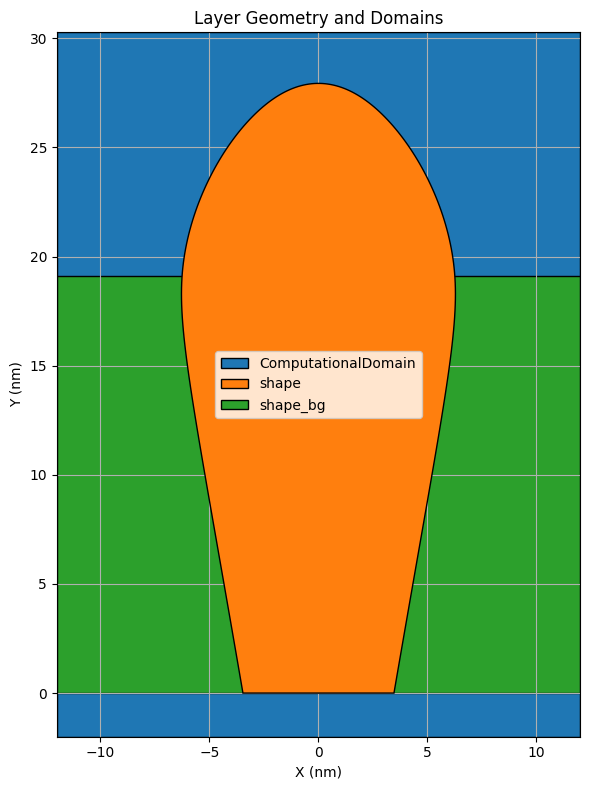

In [16]:
pitch = keys['pitch']

width_1 = keys['width_1']
width_2 = keys['width_2']
width_3 = keys['width_3']
width_4 = keys['width_4']

height_1 = keys['height_1']
height_2 = keys['height_2']
height_3 = keys['height_3']

heights = [0,height_1, height_2, height_3]
widths = [width_1, width_2, width_3, width_4]

height_bg = keys['height_bg']

y = top_offset+bottom_offset+max(height_bg,sum(heights))

control_points = h.build_control_points(heights, widths)

computional_domain = ShapeGenerator('rectangle', {'height':y,'width':pitch},offset_y=-bottom_offset).flatten(centered=True)
bg = ShapeGenerator('rectangle', {'height':height_bg,'width':pitch}).flatten(centered=True)
shape = ShapeGenerator('bsplines', {'control_points':control_points}).flatten(centered=True)

shape = [
    Shape('ComputationalDomain',domain_id = 1,priority=-1,side_length_constraint=slc,points=computional_domain, nk = 1,boundary = ['TransparentBoundary','Periodic','TransparentBoundary','Periodic'] ),
    Shape('shape',domain_id = 2,priority=2,side_length_constraint=slc,points=shape, nk = nk_PMMA ),
    Shape('shape_bg',domain_id = 3,priority=1,side_length_constraint=slc,points=bg, nk = nk_PS ),
]

# Create a shared figure and axis
fig, ax = plt.subplots(figsize=(6, 8))

# Plot each shape
for s in shape:
    #s.plot(ax=ax)
    s.plot_colored_geometry(ax=ax)

# Final touches
ax.set_xlim(-pitch/2, pitch/2)
ax.set_ylim(-bottom_offset, y-bottom_offset)
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y (nm)")
ax.set_title("Layer Geometry and Domains")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

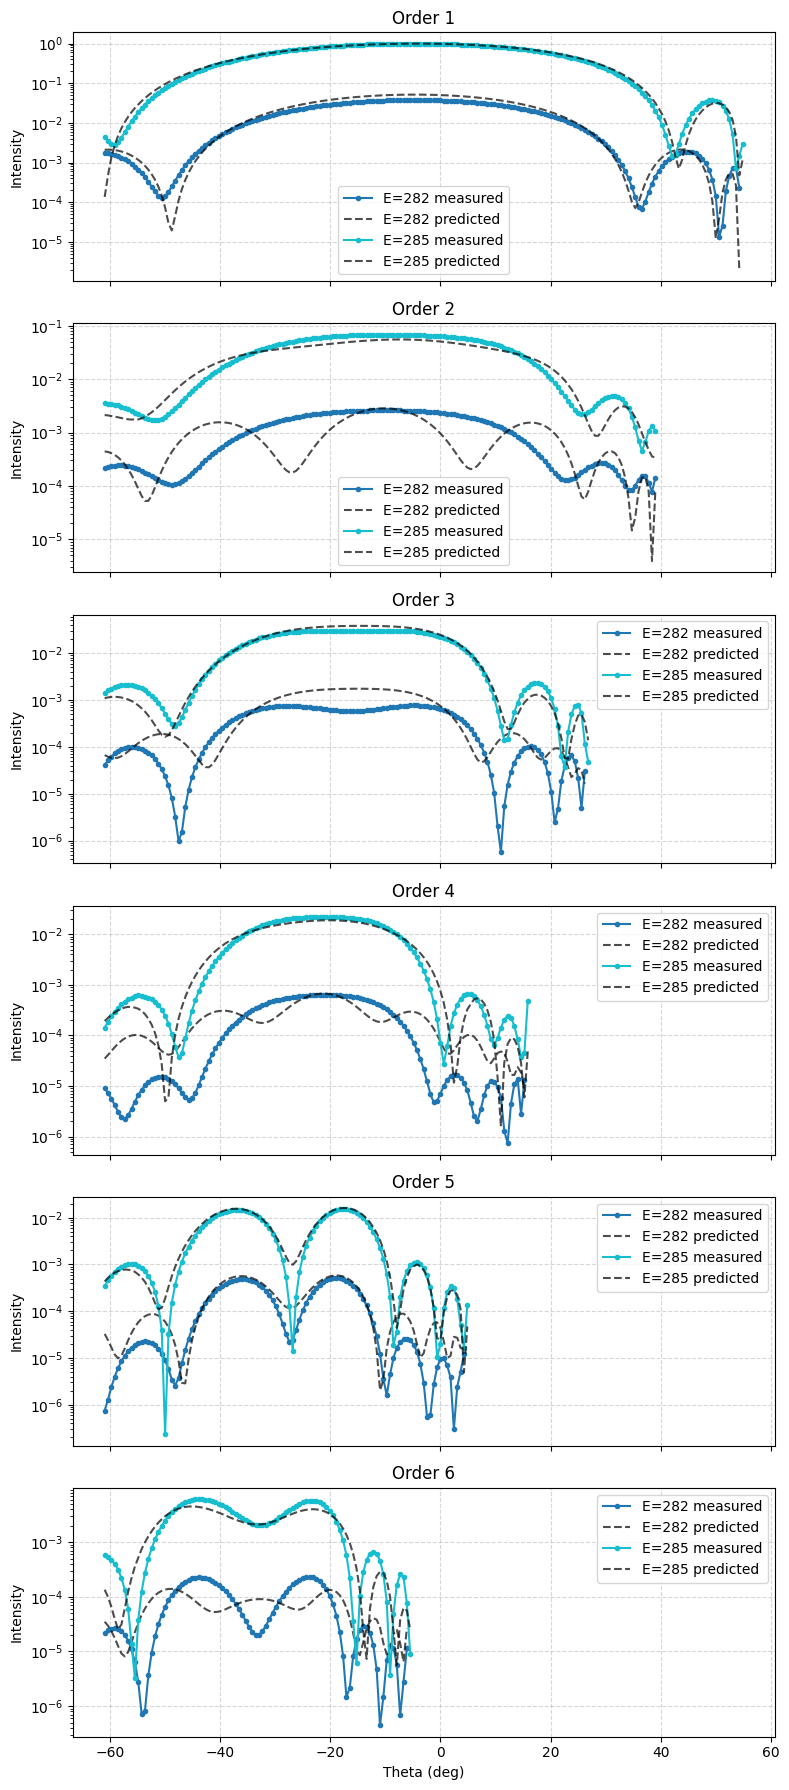

In [17]:


fig = h.plot_fit_results(merged_df.rename(columns={'intensity_norm':'exp','Intensity_calc_rough_norm':'calc'}))